In [7]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 


In [8]:
df = pd.read_csv("india_weather_rainfall_data2.csv")

In [9]:
df

,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
0,02/01/2021,January,Winter,Gulmarg,JK,Baramulla,-2.2,-6.6,-0.8,2.2,1020.0,2652,34.0500,74.4000,0.1
1,03/01/2021,January,Winter,Gulmarg,JK,Baramulla,-3.6,-4.6,-1.8,3.7,1019.5,2652,34.0500,74.4000,4.4
2,04/01/2021,January,Winter,Gulmarg,JK,Baramulla,-3.0,-4.5,-1.1,2.1,1022.0,2652,34.0500,74.4000,2.3
3,05/01/2021,January,Winter,Gulmarg,JK,Baramulla,-3.3,-5.1,-1.2,2.8,1015.6,2652,34.0500,74.4000,35.0
4,06/01/2021,January,Winter,Gulmarg,JK,Baramulla,-3.9,-8.3,-1.0,3.4,1015.3,2652,34.0500,74.4000,25.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948371,06/02/2025,February,Winter,Vizagapatam / Gajuwaka,AP,Visakhapatnam,27.3,22.0,34.0,7.6,1011.4,5,17.7167,83.2333,0.0
948372,07/02/2025,February,Winter,Vizagapatam / Gajuwaka,AP,Visakhapatnam,26.7,23.0,30.0,7.7,1013.1,5,17.7167,83.2333,0.3
948373,08/02/2025,February,Winter,Vizagapatam / Gajuwaka,AP,Visakhapatnam,26.5,23.0,30.0,8.7,1013.0,5,17.7167,83.2333,0.0
948374,09/02/2025,February,Winter,Vizagapatam / Gajuwaka,AP,Visakhapatnam,26.5,23.0,30.0,8.5,1012.8,5,17.7167,83.2333,0.0


In [10]:
df.head()

,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
0,02/01/2021,January,Winter,Gulmarg,JK,Baramulla,-2.2,-6.6,-0.8,2.2,1020.0,2652,34.05,74.4,0.1
1,03/01/2021,January,Winter,Gulmarg,JK,Baramulla,-3.6,-4.6,-1.8,3.7,1019.5,2652,34.05,74.4,4.4
2,04/01/2021,January,Winter,Gulmarg,JK,Baramulla,-3.0,-4.5,-1.1,2.1,1022.0,2652,34.05,74.4,2.3
3,05/01/2021,January,Winter,Gulmarg,JK,Baramulla,-3.3,-5.1,-1.2,2.8,1015.6,2652,34.05,74.4,35.0
4,06/01/2021,January,Winter,Gulmarg,JK,Baramulla,-3.9,-8.3,-1.0,3.4,1015.3,2652,34.05,74.4,25.5


In [11]:
df.isnull().sum()

date_of_record    0
month             0
season            0
station_name      0
state             0
district          0
avg_temp          0
min_temp          0
max_temp          0
wind_speed        0
air_pressure      0
elevation         0
latitude          0
longitude         0
rainfall          0
dtype: int64

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 948376 entries, 0 to 948375
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   date_of_record  948376 non-null  str    
 1   month           948376 non-null  str    
 2   season          948376 non-null  str    
 3   station_name    948376 non-null  str    
 4   state           948376 non-null  str    
 5   district        948376 non-null  str    
 6   avg_temp        948376 non-null  float64
 7   min_temp        948376 non-null  float64
 8   max_temp        948376 non-null  float64
 9   wind_speed      948376 non-null  float64
 10  air_pressure    948376 non-null  float64
 11  elevation       948376 non-null  int64  
 12  latitude        948376 non-null  float64
 13  longitude       948376 non-null  float64
 14  rainfall        948376 non-null  float64
dtypes: float64(8), int64(1), str(6)
memory usage: 149.5 MB


#DATA VISUALIZATION

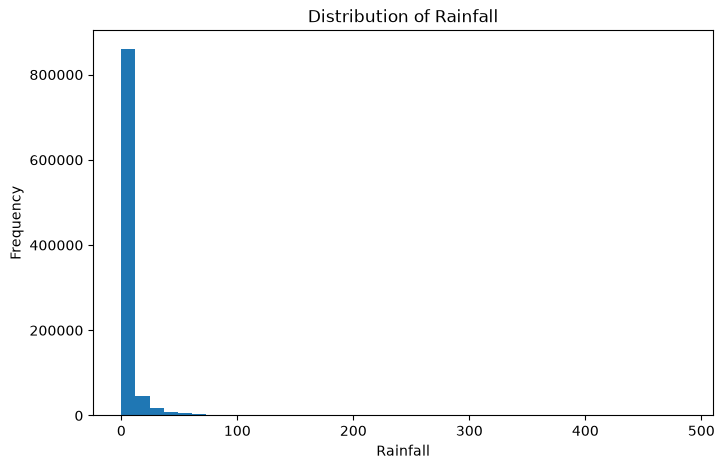

In [13]:
#rainfall distribution (histogram)

plt.figure(figsize=(8,5))
plt.hist(df['rainfall'], bins=40)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall")
plt.ylabel("Frequency")
plt.show()

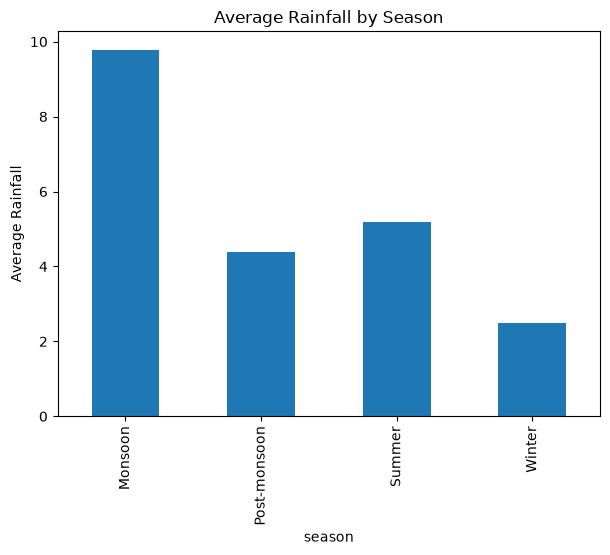

In [14]:
#Average rainfall by season

season_rain = df.groupby('season')['rainfall'].mean()

season_rain.plot(kind='bar', figsize=(7,5))
plt.title("Average Rainfall by Season")
plt.ylabel("Average Rainfall")
plt.show()

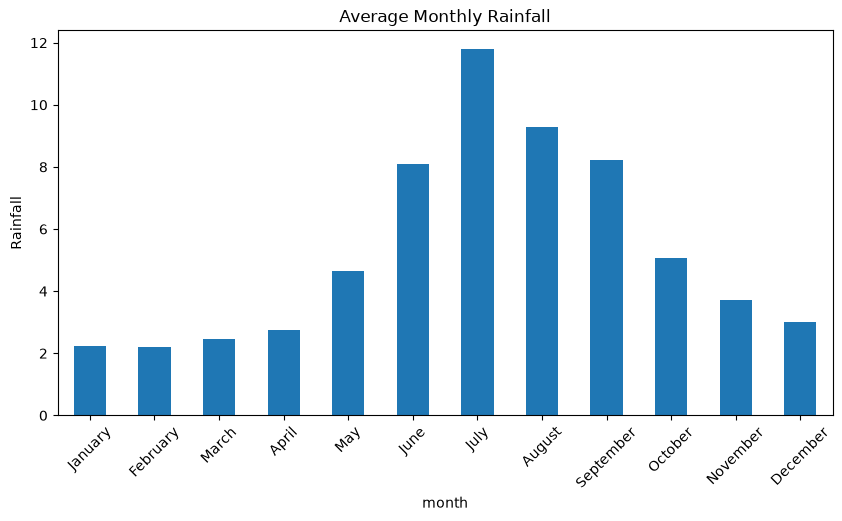

In [15]:
#Average rainfall by month
month_order = ['January','February','March','April','May','June',
            'July','August','September','October','November','December']

monthly = df.groupby('month')['rainfall'].mean().reindex(month_order)

monthly.plot(kind='bar', figsize=(10,5))
plt.title("Average Monthly Rainfall")
plt.ylabel("Rainfall")
plt.xticks(rotation=45)
plt.show()

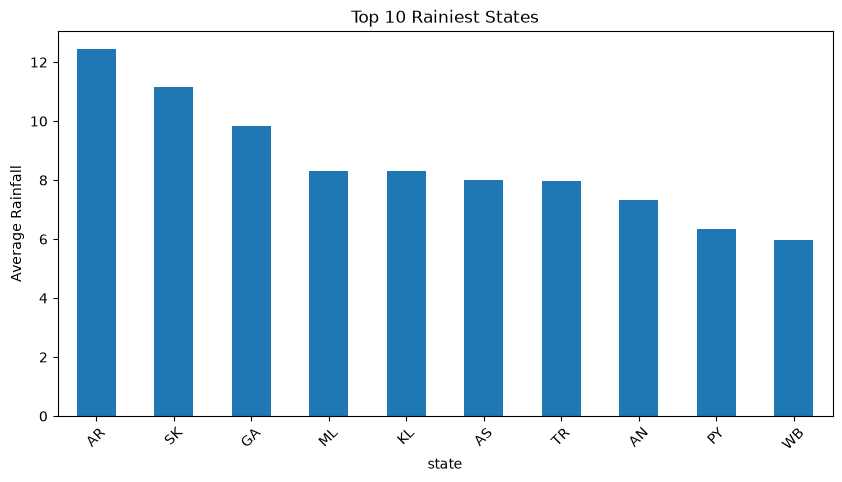

In [16]:
#Top 10 states with highest rainfall
top_states = df.groupby('state')['rainfall'].mean().sort_values(ascending=False).head(10)

top_states.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Rainiest States")
plt.ylabel("Average Rainfall")
plt.xticks(rotation=45)
plt.show()

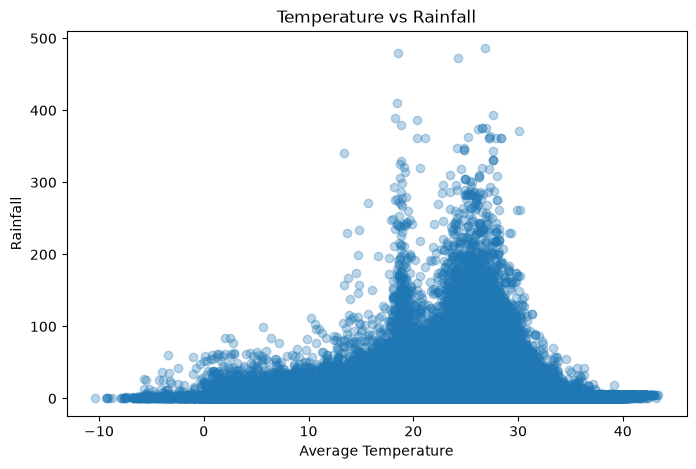

In [17]:
#temperature vs rainfall(scatterplot)
plt.figure(figsize=(8,5))
plt.scatter(df['avg_temp'], df['rainfall'], alpha=0.3)
plt.xlabel("Average Temperature")
plt.ylabel("Rainfall")
plt.title("Temperature vs Rainfall")
plt.show()

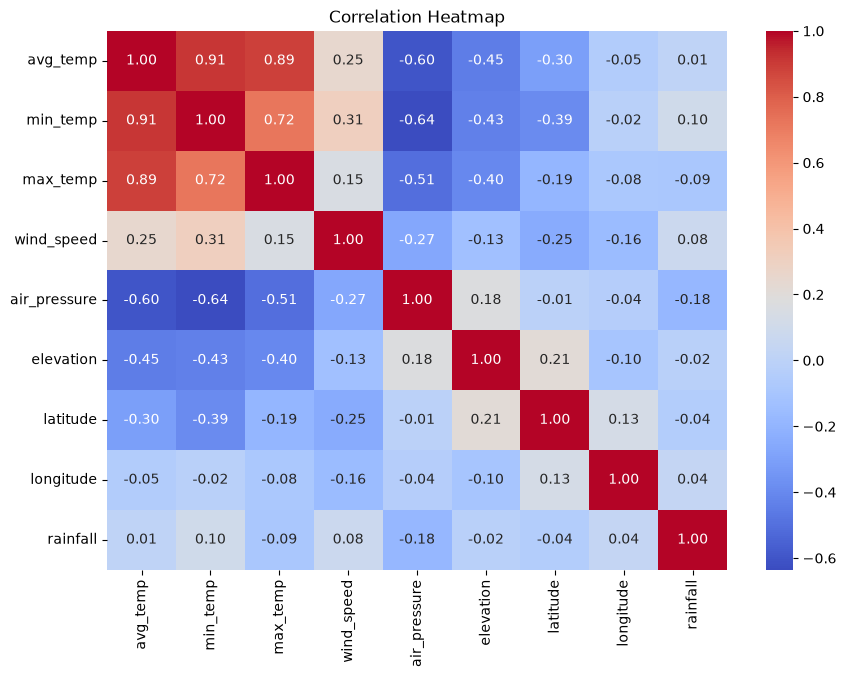

In [18]:
#correlation heatmap

plt.figure(figsize=(10,7))

corr = df[['avg_temp','min_temp','max_temp',
           'wind_speed','air_pressure',
           'elevation','latitude',
           'longitude','rainfall']].corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

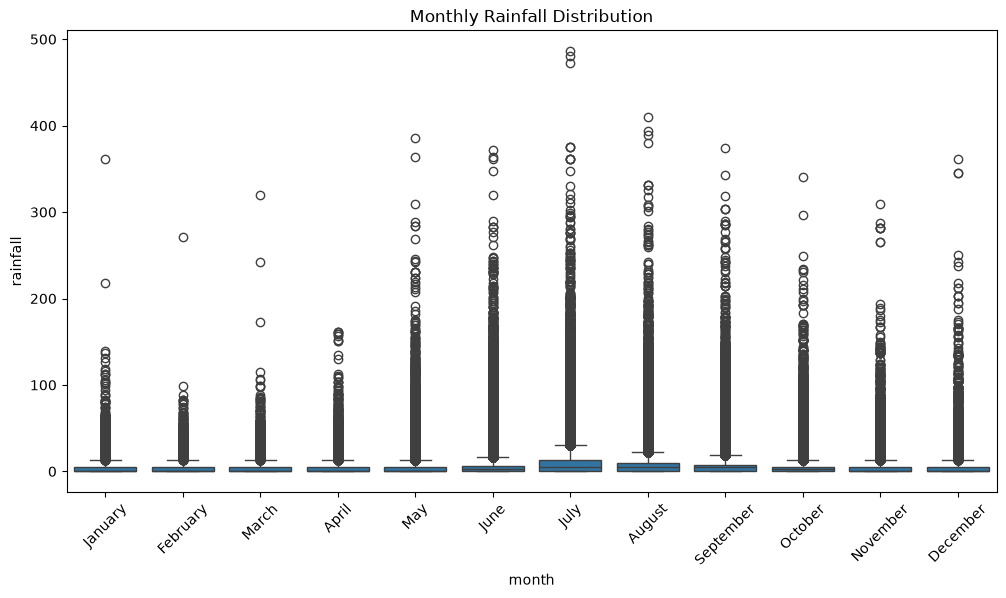

In [19]:
#rainfall by month(boxplot)
plt.figure(figsize=(12,6))
sns.boxplot(x='month', y='rainfall', data=df, order=month_order)
plt.xticks(rotation=45)
plt.title("Monthly Rainfall Distribution")
plt.show()

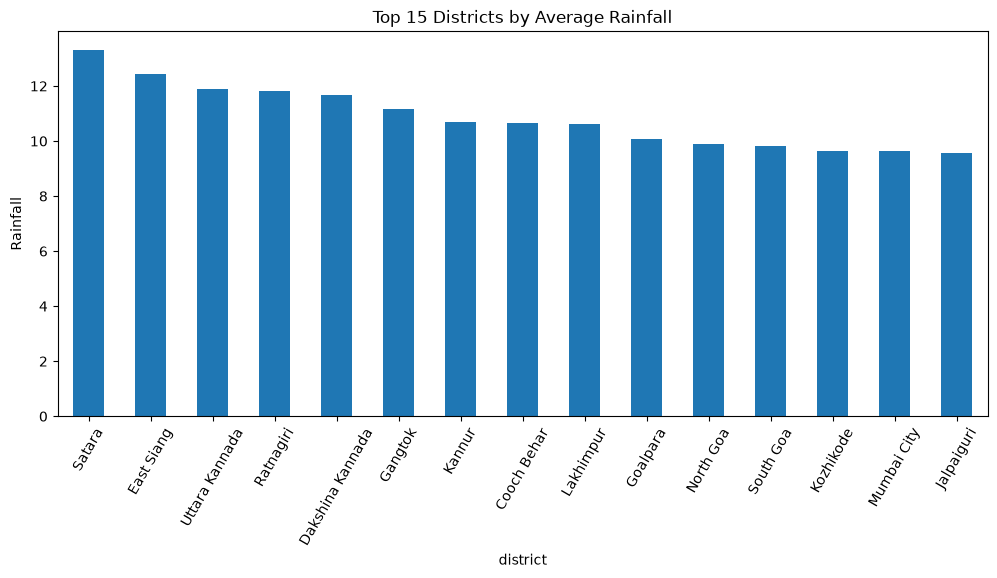

In [20]:
#top 15 districts with highest rainfall
top_districts = df.groupby('district')['rainfall'].mean().sort_values(ascending=False).head(15)

top_districts.plot(kind='bar', figsize=(12,5))
plt.title("Top 15 Districts by Average Rainfall")
plt.ylabel("Rainfall")
plt.xticks(rotation=60)
plt.show()

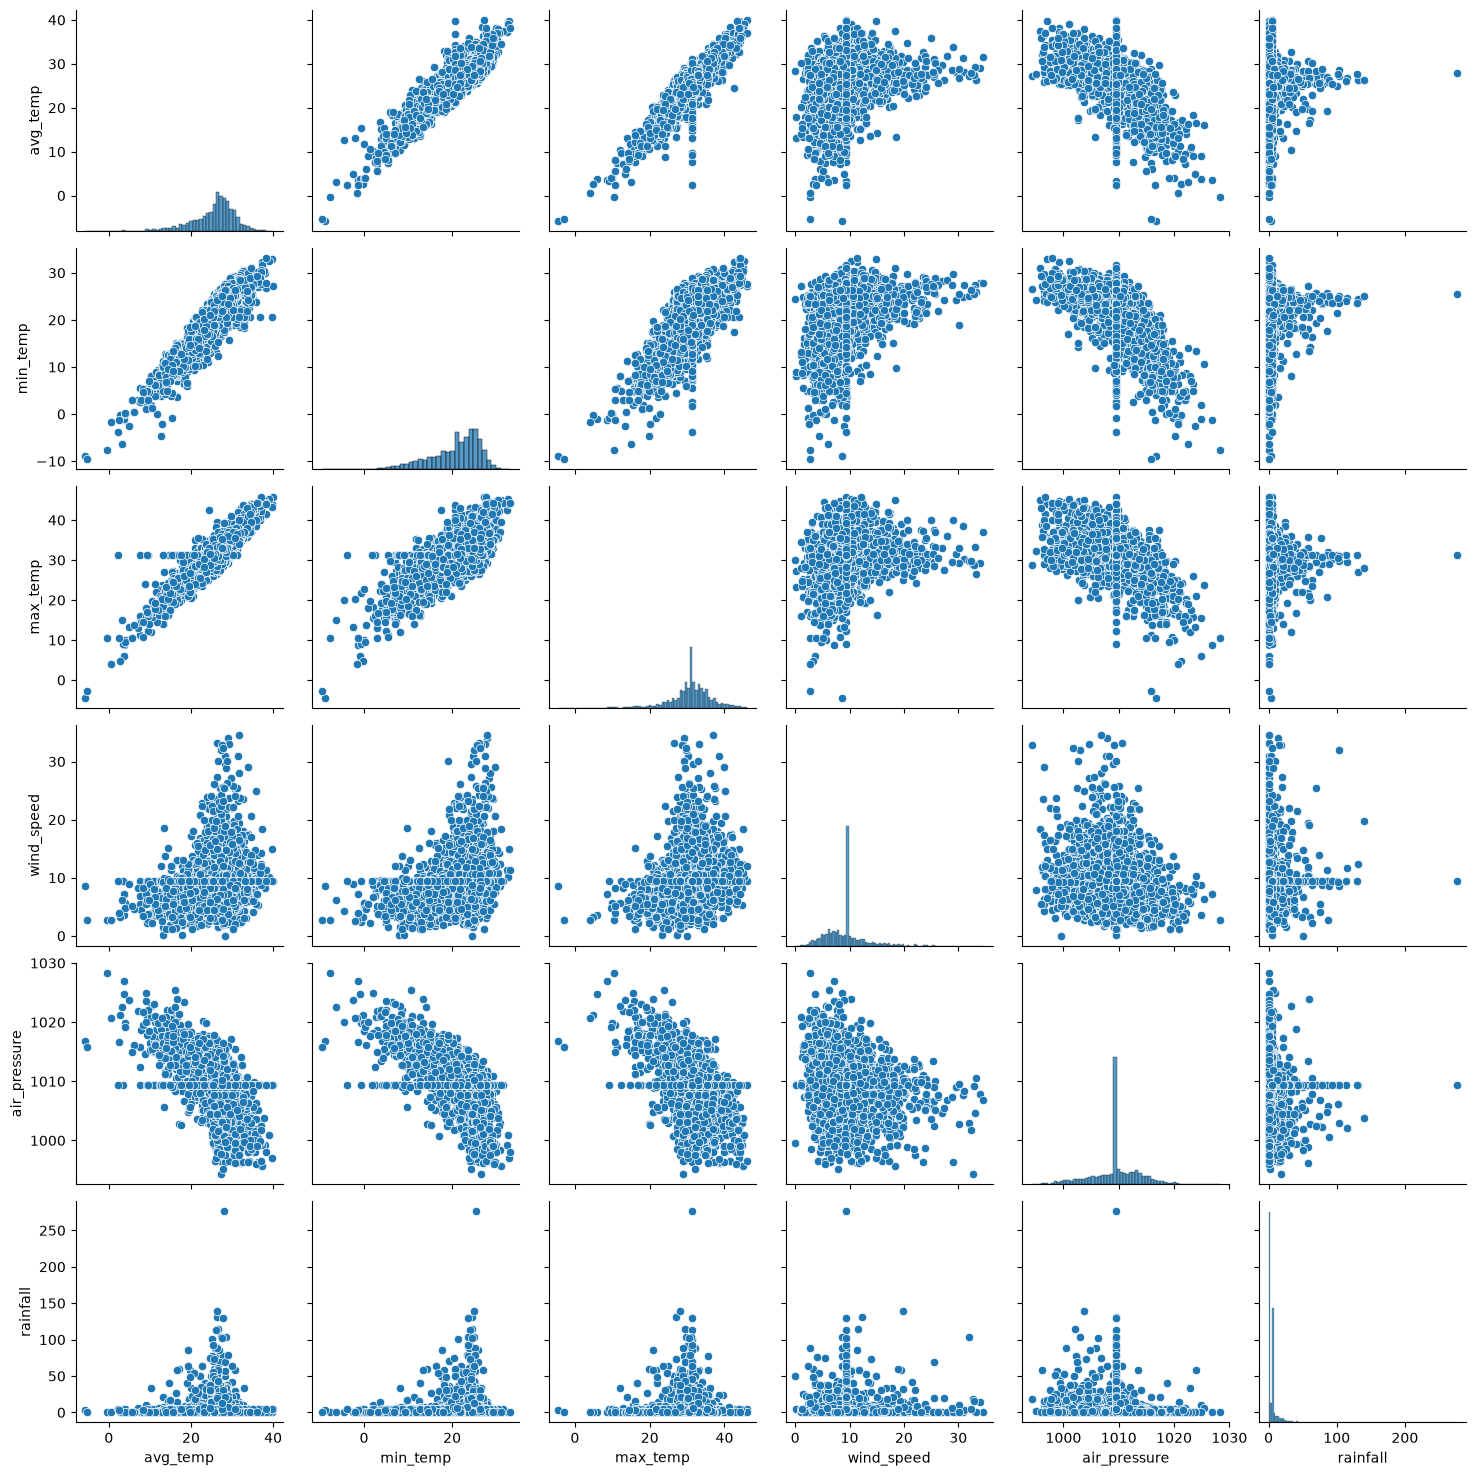

In [21]:
#correlation pairplot
sns.pairplot(df[['avg_temp',
                 'min_temp',
                 'max_temp',
                 'wind_speed',
                 'air_pressure',
                 'rainfall']].sample(3000))

plt.show()

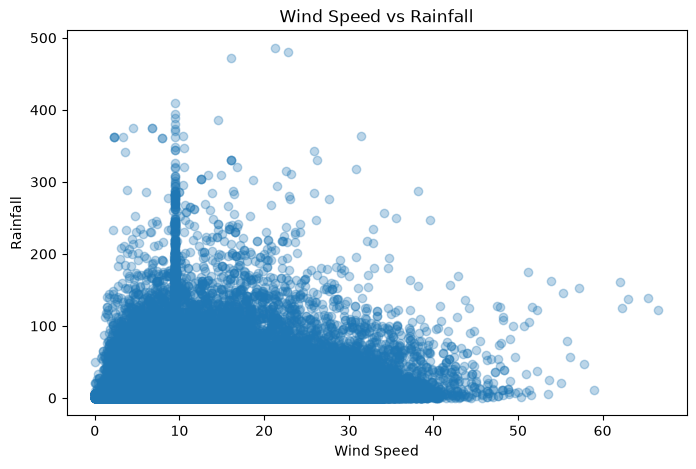

In [22]:
#win speed vs rainfall
plt.figure(figsize=(8,5))
plt.scatter(df['wind_speed'], df['rainfall'], alpha=0.3)
plt.xlabel("Wind Speed")
plt.ylabel("Rainfall")
plt.title("Wind Speed vs Rainfall")
plt.show()

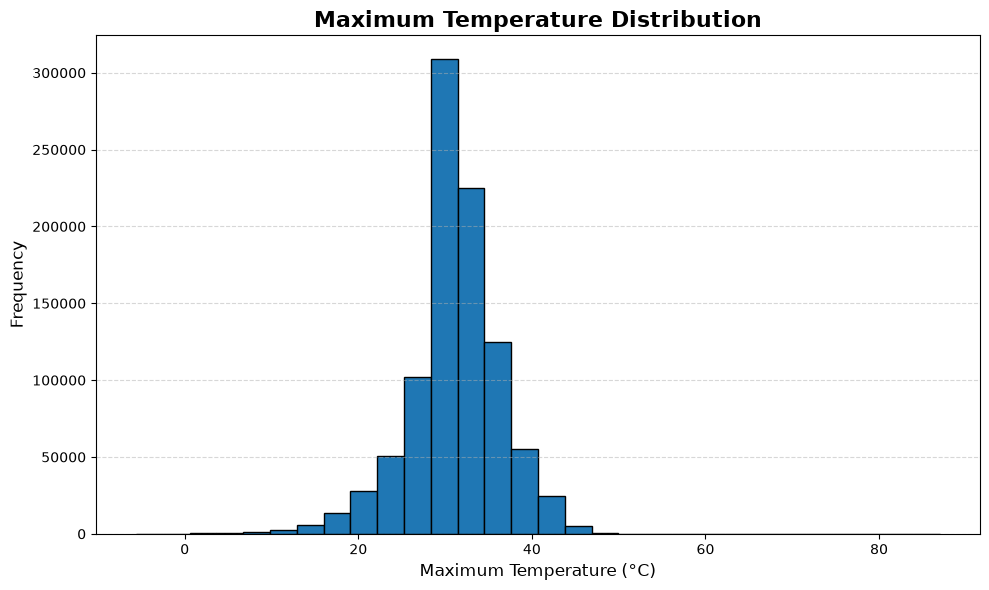

In [68]:
#Maximum Temperature Distribution
df['max_temp'] = pd.to_numeric(df['max_temp'], errors='coerce')
max_temp = df['max_temp'].dropna()
plt.figure(figsize=(10,6))
plt.hist(
    max_temp,
    bins=30,
    color='#1f77b4',
    edgecolor='black',
    linewidth=1
)
plt.title("Maximum Temperature Distribution",
          fontsize=16,
          fontweight='bold')
plt.xlabel("Maximum Temperature (°C)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

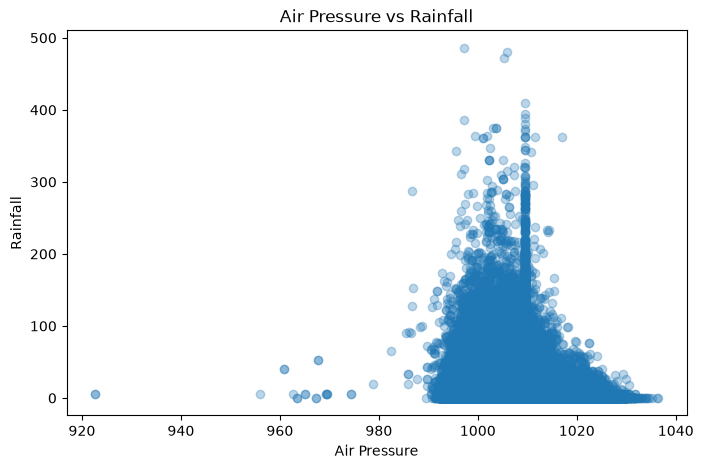

In [69]:
#air pressure vs rainfall
plt.figure(figsize=(8,5))
plt.scatter(df['air_pressure'], df['rainfall'], alpha=0.3)
plt.xlabel("Air Pressure")
plt.ylabel("Rainfall")
plt.title("Air Pressure vs Rainfall")
plt.show()

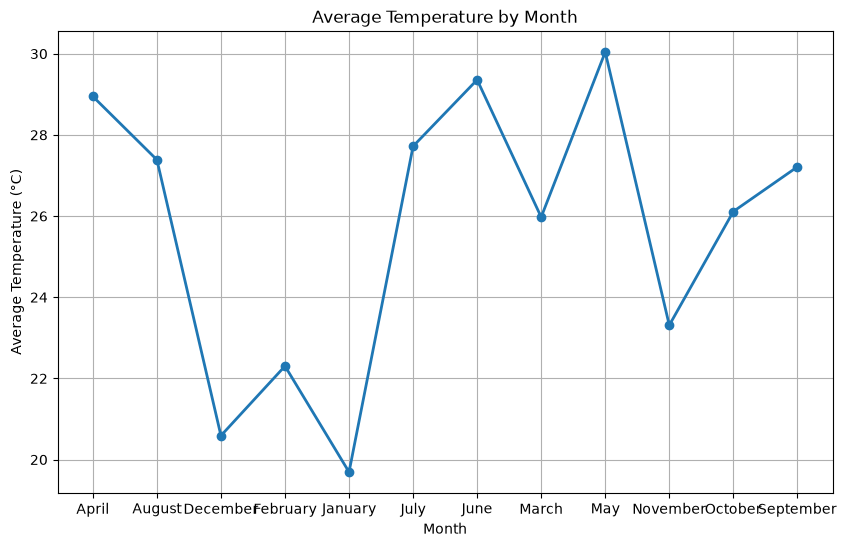

In [70]:
#Average temperature by month
monthly_temp = df.groupby('month')['avg_temp'].mean()

plt.figure(figsize=(10,6))
plt.plot(monthly_temp.index,
         monthly_temp.values,
         marker='o',
         linewidth=2)

plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)
plt.show()

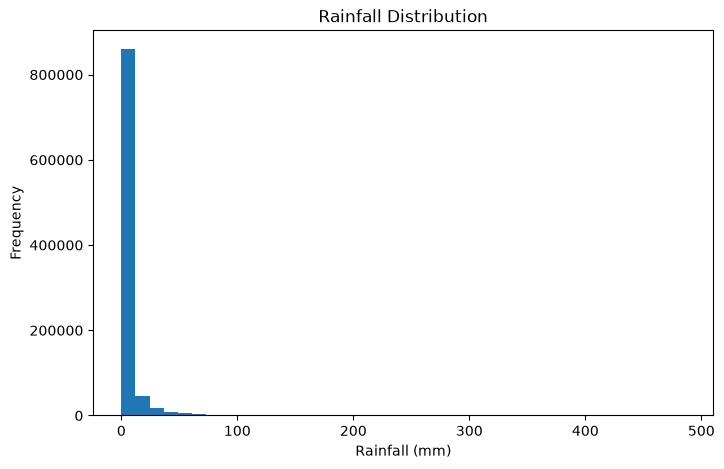

In [71]:
#Minimum Temperature Distribution (histogram)

plt.figure(figsize=(8,5))
plt.hist(df['rainfall'], bins=40)
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

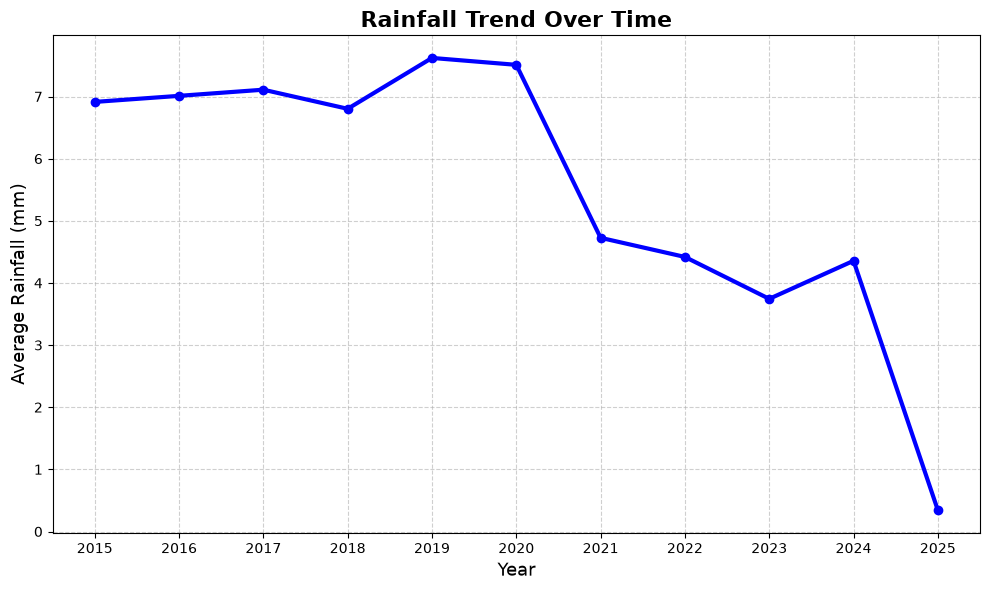

In [72]:
#Rainfall Trend Over Time
df['date_of_record'] = pd.to_datetime(
    df['date_of_record'],
    format='%d/%m/%Y'
)
df['Year'] = df['date_of_record'].dt.year
yearly_rainfall = df.groupby('Year')['rainfall'].mean().reset_index()
plt.figure(figsize=(10,6))

plt.plot(yearly_rainfall['Year'],
         yearly_rainfall['rainfall'],
         marker='o',
         linestyle='-',
         linewidth=3,
         color='blue')

plt.title("Rainfall Trend Over Time", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=13)
plt.ylabel("Average Rainfall (mm)", fontsize=13)

plt.xticks(yearly_rainfall['Year'])
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

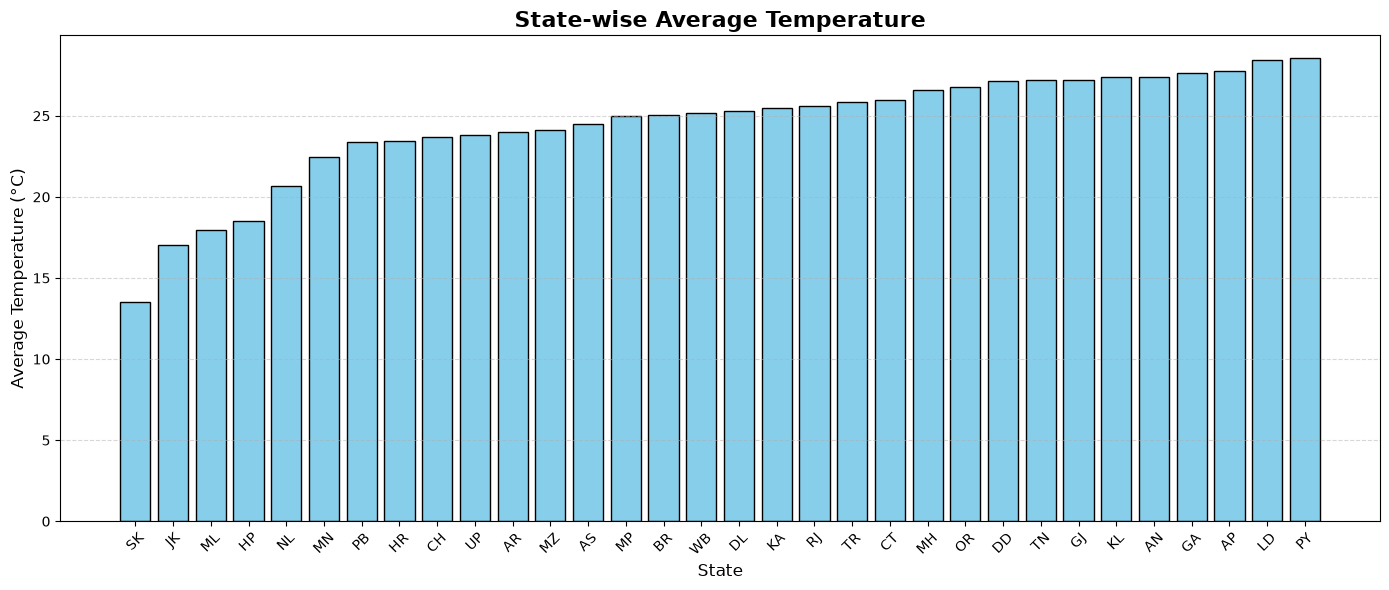

In [73]:
#State-wise average temperature
state_temp = df.groupby('state')['avg_temp'].mean().sort_values(ascending=True)
plt.figure(figsize=(14,6))
plt.bar(state_temp.index,
        state_temp.values,
        color='skyblue',
        edgecolor='black')

plt.title("State-wise Average Temperature", fontsize=16, fontweight='bold')
plt.xlabel("State", fontsize=12)
plt.ylabel("Average Temperature (°C)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

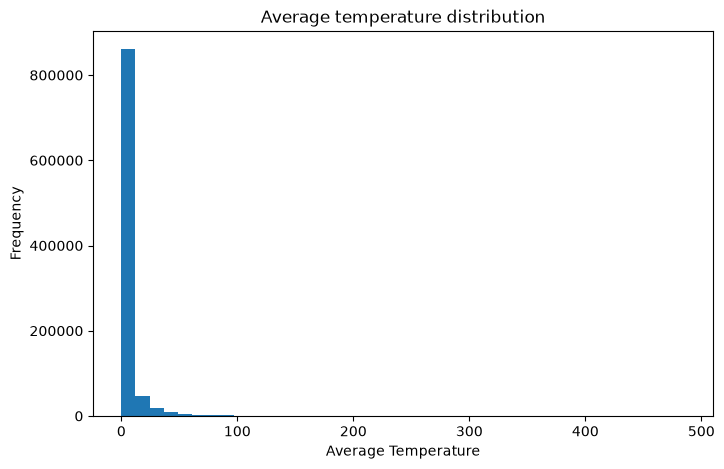

In [74]:
#Average temperature distribution (histogram)

plt.figure(figsize=(8,5))
plt.hist(df['rainfall'], bins=40)
plt.title("Average temperature distribution")
plt.xlabel("Average Temperature")
plt.ylabel("Frequency")
plt.show()